# Equalization per RGB channel

In [16]:
from google.colab import drive
drive.mount('/content/drive/')
import plotly.express as px
import imageio.v3 as iio
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import skimage as ski

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [17]:
img = iio.imread(uri='/content/drive/MyDrive/Colab Notebooks/images/low_contrast2.jpg')
img_rgb = img[:, :, :3]

## Global equalization per channel

In [18]:
from skimage import exposure

eq_rgb = np.zeros_like(img_rgb)

for c in range(3):
  eq=exposure.equalize_hist(img_rgb[:, :, c])
  eq_rgb[:, :, c] = (eq*255).astype(np.uint8)

## CLAHE  per channel

In [19]:
clahe_rgb_1 = np.zeros_like(img_rgb)
clahe_rgb_5 = np.zeros_like(img_rgb)


for c in range(3):
  clahe_1=exposure.equalize_adapthist(img_rgb[:, :, c], clip_limit=0.01)
  clahe_5=exposure.equalize_adapthist(img_rgb[:,:,c], clip_limit=0.005)

  clahe_rgb_1[:,:,c] = (clahe_1*255).astype(np.uint8)
  clahe_rgb_5[:,:,c] = (clahe_5*255).astype(np.uint8)

## Plot histograms


In [20]:
def plot_rgb_histograms(img, title):
    colors = ["red", "green", "blue"]
    fig, ax = plt.subplots(1, 3, figsize=(15,4))

    for i, color in enumerate(colors):
        hist, bins = np.histogram(img[:, :, i], bins=256, range=(0,256))
        ax[i].bar(bins[:-1], hist, color=color)
        ax[i].set_title(f"{title} – {color.upper()}")
        ax[i].set_xlim([0,256])

    plt.tight_layout()
    plt.show()


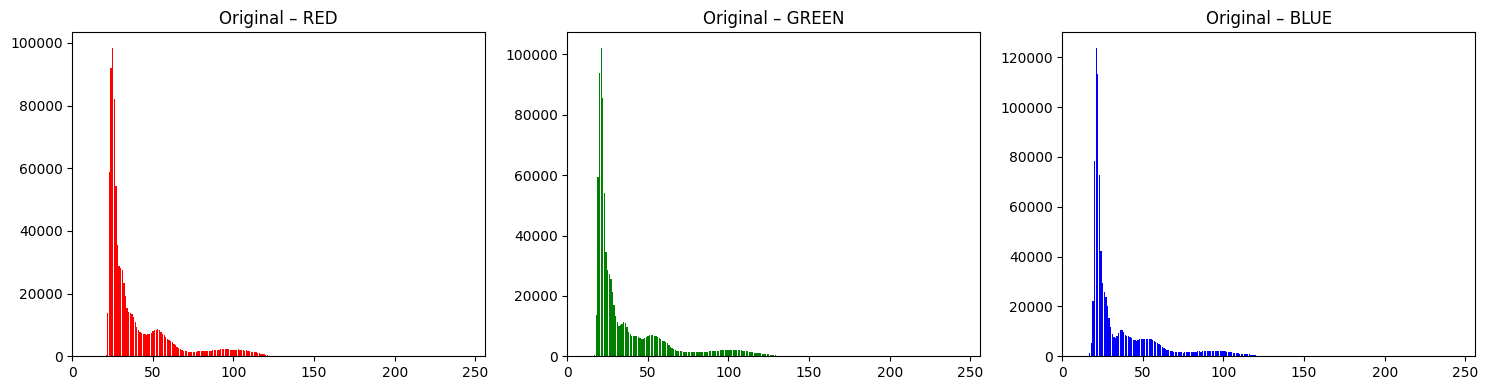

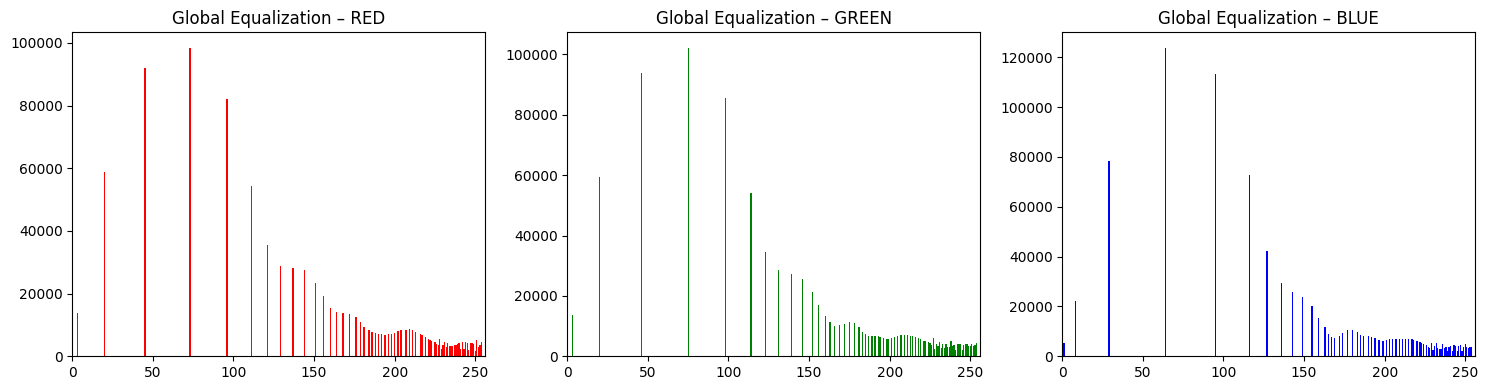

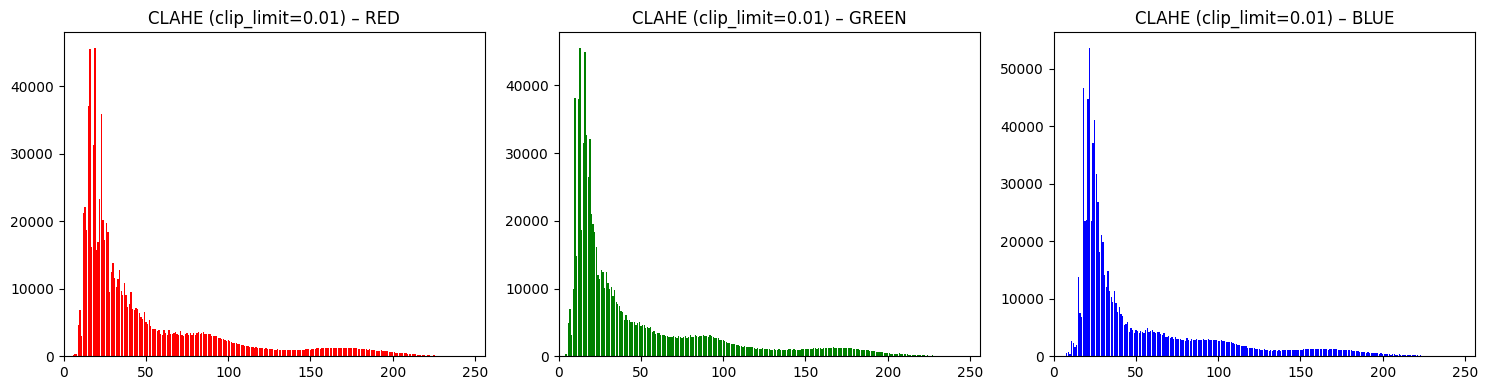

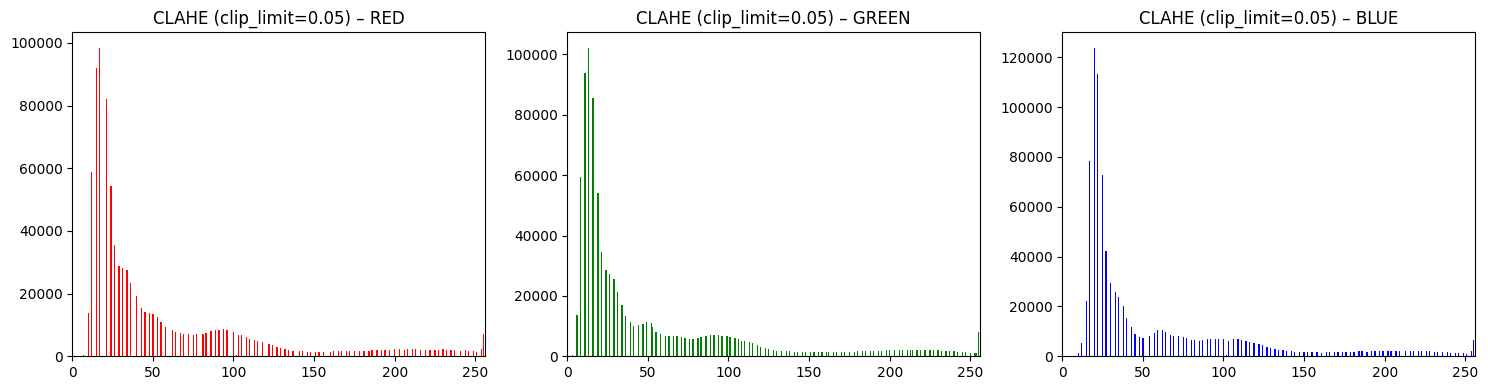

In [22]:
plot_rgb_histograms(img_rgb, "Original")
plot_rgb_histograms(eq_rgb, "Global Equalization")
plot_rgb_histograms(clahe_rgb_1, "CLAHE (clip_limit=0.01)")
plot_rgb_histograms(clahe_rgb_5, "CLAHE (clip_limit=0.05)")


## Contrast stretching

In [24]:
img_array = img[:,:,:1]
min_val = np.min(img_array)
max_val = np.max(img_array)

img_stretch = (img_array-min_val)*255 / (max_val - min_val)
img_stretch = img_stretch.astype(np.uint8)
# Instead of min/max (which can be affected by outliers)
# p2, p98 = np.percentile(img_array, (2, 98))
# img_stretch = np.clip((img_array - p2) * 255.0 / (p98 - p2), 0, 255).astype(np.uint8)

In [27]:
img_eq= exposure.equalize_hist(img_array)
img_eq=(img_eq*255).astype(np.uint8)

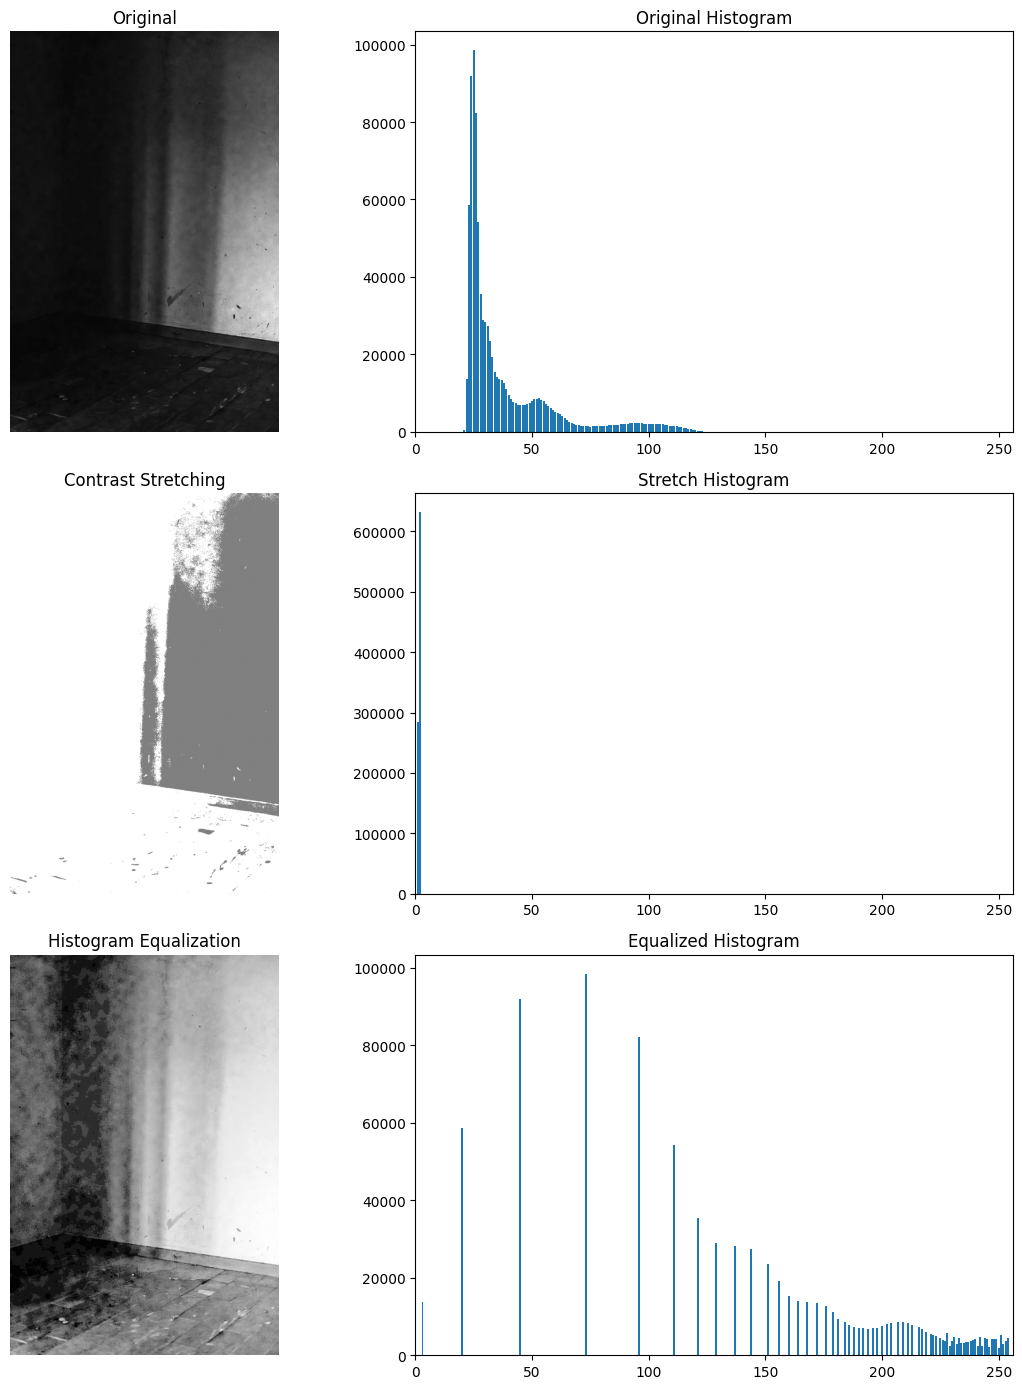

In [29]:
import matplotlib.pyplot as plt

# Histograms
hist_orig, bins = np.histogram(img_array, bins=256, range=(0,256))
hist_st, _      = np.histogram(img_stretch, bins=256, range=(0,256))
hist_eq, _      = np.histogram(img_eq, bins=256, range=(0,256))

fig, ax = plt.subplots(3, 2, figsize=(12, 14))

# Original
ax[0,0].set_title("Original")
ax[0,0].imshow(img_array, cmap="gray"); ax[0,0].axis("off")
ax[0,1].set_title("Original Histogram")
ax[0,1].bar(bins[:-1], hist_orig); ax[0,1].set_xlim([0,256])

# Contrast stretched
ax[1,0].set_title("Contrast Stretching")
ax[1,0].imshow(img_stretch, cmap="gray"); ax[1,0].axis("off")
ax[1,1].set_title("Stretch Histogram")
ax[1,1].bar(bins[:-1], hist_st); ax[1,1].set_xlim([0,256])

# Equalized
ax[2,0].set_title("Histogram Equalization")
ax[2,0].imshow(img_eq, cmap="gray"); ax[2,0].axis("off")
ax[2,1].set_title("Equalized Histogram")
ax[2,1].bar(bins[:-1], hist_eq); ax[2,1].set_xlim([0,256])

plt.tight_layout()
plt.show()
